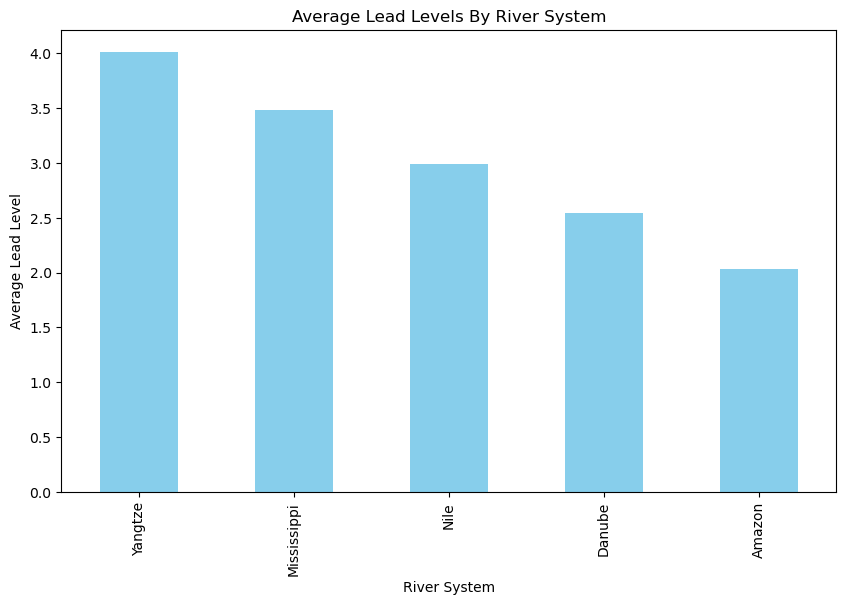

<Figure size 1000x600 with 0 Axes>

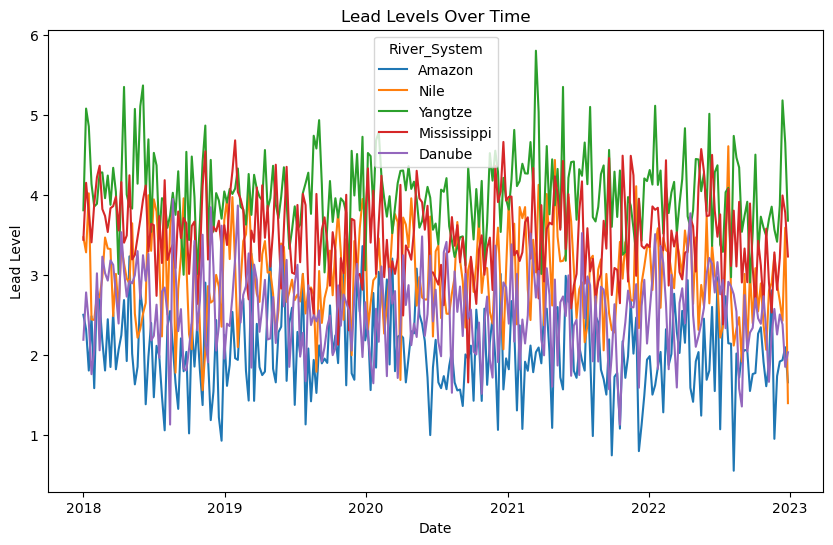

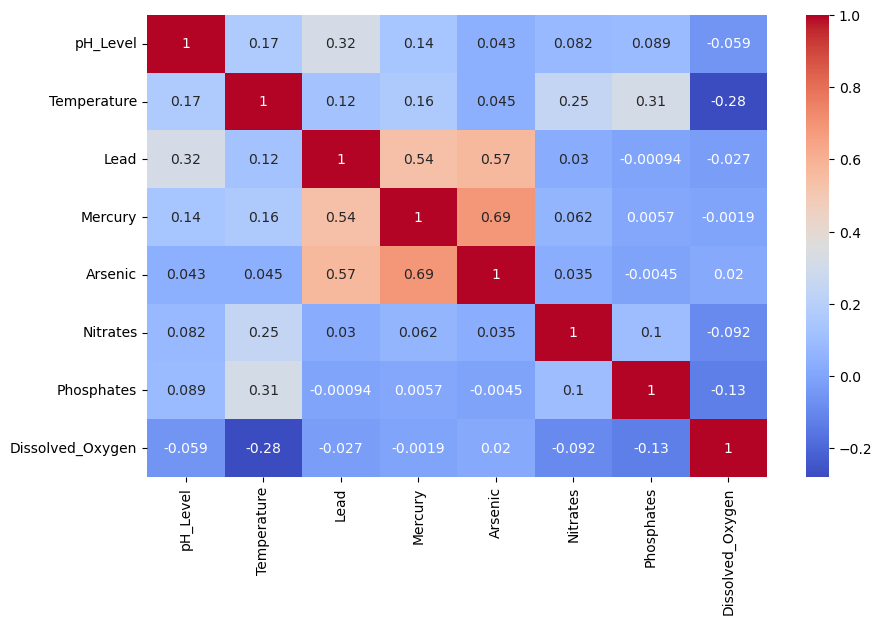

T-test between Amazon and Nile: T-statistic = -20.23821779031797, P-value = 1.3375120881428663e-67
Linear Regression Coefficients: [0.80294889]


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Load the dataset

data = pd.read_csv('/Users/Macbook/Documents/Jupyter/National_River_Toxin_Dataset_1.csv')

# Intial data exploration
# print(data.head())
# print(data.info())
# print(data.describe())

# Check for missing values

# print(data.isnull().sum())

# Fill missing values with numeric values only 

numeric_columns = data.select_dtypes(include=[np.number]).columns
data[numeric_columns] = data[numeric_columns].fillna(
    data[numeric_columns].mean()
)
# Convert the date column to datetime

data['Date'] =pd.to_datetime(data['Date'])

# Calculate the average level of toxins
average_toxin_levels = data[['Lead', 'Mercury', 'Arsenic']].mean()
# print(f"Average Toxin Levels:\n{average_toxin_levels}")

# Identify top polluted rivers by average Lead levels
top_polluted_rivers = data.groupby('River_System')['Lead'].mean().sort_values(ascending=False)
# print(f"Top Polluted Rivers By Lead Levels:\n{top_polluted_rivers.head()}")

# Bar chart for average Lead Levels
plt.figure(figsize=(10,6))
top_polluted_rivers.plot(kind='bar', color='skyblue')
plt.title('Average Lead Levels By River System')
plt.xlabel('River System')
plt.ylabel('Average Lead Level')
plt.show()

# Line graph for toxin levels over time
plt.figure(figsize=(10,6))
plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Lead', data=data, hue='River_System', errorbar=None)
errorbar=None
plt.title('Lead Levels Over Time')
plt.xlabel('Date')
plt.ylabel('Lead Level')
plt.show()

# Compute the correlation matric using numeric values
corr_matrix = data[numeric_columns].corr()

# Heatmap for correlation between different parameters 
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# T-test between two river systems (e.g. Amazon and Nile)
amazon_data = data[data['River_System'] == 'Amazon']['Lead']
nile_data = data[data['River_System'] == 'Nile']['Lead']
t_stat, p_value = stats.ttest_ind(amazon_data, nile_data)

print(f"T-test between Amazon and Nile: T-statistic = {t_stat}, P-value = {p_value}")

# Linear regression analysis for toxin levels and pH

X = data[['pH_Level']]
y = data['Lead']
model = LinearRegression()
model.fit(X, y)
print(f"Linear Regression Coefficients: {model.coef_}")
